# L02 · K 线读图 + DataFrame 索引

**预计时长**：60 min | **难度**：⭐⭐ | **前置**：L01

## 本节目标
1. 看懂 K 线 4 元素（OHLC）、阳线阴线、上下影、典型形态
2. 用 mplfinance 画专业 K 线图（替代 L01 的纯数字表）
3. 掌握 DataFrame 的 `.loc / .iloc` 索引切片
4. 从 K 线上定位"最大涨/跌幅日"并理解为什么

## 第 1 段：金融概念

### K 线构成（单根）
```
     最高 ───┐       ← 上影线
             │
      ┌──────┴──────┐  ← 收盘价（阳线）
      │             │
      │   实体      │
      │             │
      └──────┬──────┘  ← 开盘价（阳线）
             │
     最低 ───┘       ← 下影线
```
- **阳线（红 / A 股惯例）**：close > open，看涨
- **阴线（绿 / A 股惯例）**：close < open，看跌
- **上影**：high - max(open, close)，代表"上方抛压"
- **下影**：min(open, close) - low，代表"下方支撑"

**注意**：A 股红涨绿跌，和美股相反！后续所有图按 A 股惯例。

### 典型形态（4 例）
| 形态 | 特征 | 含义 |
|------|------|------|
| 大阳线 | 实体长、影线短 | 强势看涨 |
| 十字星 | open≈close、有上下影 | 多空胶着，可能反转 |
| 锤头线 | 下影长、实体小、无上影 | 底部反转信号 |
| 一字板 | OHLC 全相等 | 涨/跌停封死（L01 见过） |

In [5]:
import sys
from pathlib import Path

# 自动定位 phase1_foundation 目录 + project root（兼容两种 jupyter 启动位置）
_cwd = Path.cwd()
_p1 = _cwd if (_cwd / '_data.py').exists() else (_cwd / 'learning' / 'phase1_foundation')
sys.path.insert(0, str(_p1))
_proj = _p1.parent.parent if _p1.name == 'phase1_foundation' else _p1
if (_proj / 'qtrader' / '__init__.py').exists():
    sys.path.insert(0, str(_proj))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import _style
from _data import get_stock_data

In [6]:
byd = get_stock_data("002594")
byd.head()

,date,open,high,low,close,volume
0,2022-01-04,89.39,90.51,85.90,87.77,24466089.0
1,2022-01-05,85.68,86.31,81.53,82.02,30170891.0
2,2022-01-06,80.97,82.44,80.29,80.98,17590784.0
3,2022-01-07,81.55,81.93,79.35,79.84,16193355.0
4,2022-01-10,79.35,80.80,77.42,79.77,16214182.0


## 第 2 段：手画一根 K 线（理解本质）

用 matplotlib 矩形 + 线段画一根 K 线，让你看清 mplfinance 背后做了什么。

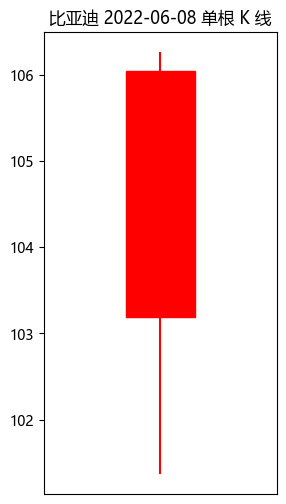

In [7]:
# 选一天比亚迪的 K 线
row = byd.iloc[100]  # 第 100 个交易日
is_up = row['close'] >= row['open']
color = 'red' if is_up else 'green'

fig, ax = plt.subplots(figsize=(3, 6))
# 上下影线
ax.plot([0, 0], [row['low'], row['high']], color=color, linewidth=1.5)
# 实体矩形
body_low = min(row['open'], row['close'])
body_high = max(row['open'], row['close'])
ax.add_patch(plt.Rectangle((-0.3, body_low), 0.6, body_high - body_low,
                            facecolor=color, edgecolor=color))
ax.set_xlim(-1, 1)
ax.set_title(f"比亚迪 {row['date'].date()} 单根 K 线")
ax.set_xticks([])
plt.show()

## 第 3 段：mplfinance 专业 K 线图

手画太累。`mplfinance` 一行画出几十根 K 线 + 均线 + 成交量。

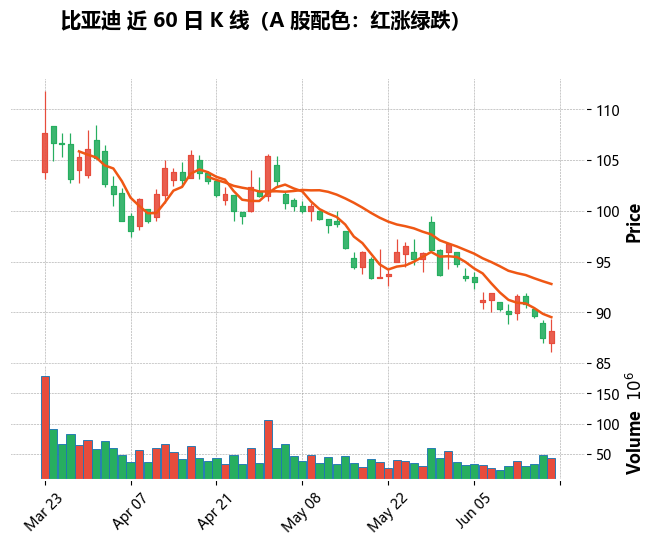

In [8]:
import mplfinance as mpf

# 自定义 A 股配色（红涨绿跌，与美股相反）
a_share_style = mpf.make_mpf_style(
    base_mpf_style='charles',
    marketcolors=mpf.make_marketcolors(up='#e74c3c', down='#27ae60',
                                        edge='inherit', wick='inherit',
                                        volume='inherit'),
    rc={'font.sans-serif': ['Microsoft YaHei']},
)

# mplfinance 要求 DataFrame 的 index 是 DatetimeIndex，列名是 Open/High/Low/Close/Volume
df = byd.set_index('date').rename(columns={
    'open': 'Open', 'high': 'High', 'low': 'Low',
    'close': 'Close', 'volume': 'Volume'
})
# 取最近 60 个交易日
df_recent = df.tail(60)
mpf.plot(df_recent, type='candle', style=a_share_style,
         title='比亚迪 近 60 日 K 线（A 股配色：红涨绿跌）',
         volume=True, mav=(5, 20))

**A 股配色**：红涨绿跌（与美股相反）。上面用 `mpf.make_marketcolors(up='#e74c3c', down='#27ae60')` 自定义。

## 第 4 段：`.loc / .iloc` 索引切片

- `.loc`：按**标签**（日期、列名）索引
- `.iloc`：按**位置**（整数下标）索引

In [14]:
# 1. 用 .loc 选某一段日期（要用日期 index）
byd_indexed = byd.set_index('date')
slice1 = byd_indexed.loc['2026-06-08':'2026-06-12']
print(f"2024 Q1 行数: {len(slice1)}")
slice1.head()

2024 Q1 行数: 5


,open,high,low,close,volume
date,,,,,
2026-06-08,91.00,92.02,90.30,91.19,31684395.0
2026-06-09,91.22,91.92,90.03,91.89,28192695.0
2026-06-10,91.00,91.00,90.10,90.31,24128660.0
2026-06-11,90.10,90.80,88.88,89.80,31508734.0
2026-06-12,89.90,91.78,89.25,91.60,38535178.0


In [16]:
# 2. 用 .loc 选某些列
byd_indexed.loc['2024-01-01':'2024-01-05', ['close', 'volume']]

,close,volume
date,,
2024-01-02,62.67,11392832.0
2024-01-03,62.86,8448596.0
2024-01-04,62.81,8987036.0
2024-01-05,62.70,11240188.0


In [17]:
# 3. 用 .iloc 按位置取
print("第 1 行：")
print(byd.iloc[0])
print("\n第 10-12 行的 close 列：")
print(byd.iloc[10:13, byd.columns.get_loc('close')])

第 1 行：
date      2022-01-04 00:00:00
open                    89.39
high                    90.51
low                      85.9
close                   87.77
volume             24466089.0
Name: 0, dtype: object

第 10-12 行的 close 列：
10    86.18
11    81.93
12    81.32
Name: close, dtype: float64


In [18]:
# 4. 布尔索引（loc 的高级用法）
# 找所有 close > open 且当日涨幅 > 5% 的日子
byd['prev_close'] = byd['close'].shift(1)
byd['chg_pct'] = byd['close'] / byd['prev_close'] - 1
big_up = byd[(byd['close'] > byd['open']) & (byd['chg_pct'] > 0.05)]
print(f"比亚迪涨幅>5% 且阳线的日子共 {len(big_up)} 天")
big_up[['date', 'open', 'close', 'chg_pct']].head()

比亚迪涨幅>5% 且阳线的日子共 25 天


,date,open,close,chg_pct
6,2022-01-12,79.67,82.91,0.070635
9,2022-01-17,81.95,86.31,0.052689
19,2022-02-07,77.99,79.16,0.077740
31,2022-02-23,78.35,81.62,0.061378
46,2022-03-16,71.58,74.31,0.078207


## 第 5 段：随堂小练

### 小练：找比亚迪最近一年最大单日涨幅日的 K 线
用 mplfinance 画出那一天 ±10 个交易日的 K 线图（共 21 根），观察"最大涨幅日"长什么样。

In [19]:
# TODO: 你的代码（约 5 行）
# 提示：
# 1) 筛出最近一年的 byd 子集
# 2) idx = sub['chg_pct'].idxmax() 找到最大涨幅日的行号
# 3) 用 .iloc 取 ±10 范围
# 4) 转 mplfinance 格式后画图

## 第 6 段：课后练习 + 下节预告

### 📝 `exercises/ex02.py`
1. 写函数 `find_doji(df, tol=0.005)`：找出"十字星"（open 与 close 差异 < tol × close）的日期列表
2. 用 mplfinance 画比亚迪最近一年 K 线 + 20 日均线 + 成交量，保存为 PNG
3. 统计比亚迪 2022 至今每月"大阳线（涨幅>5%）"出现次数，画月度柱状图

### 🔮 下节 L03：量价关系 + 聚合
成交量是 K 线之外的另一根主线。学 `resample` / `rolling` / 双轴图 + 换手率概念。

## 第 7 段：Jupyter tip 🔧
- `Shift + Tab`（在函数名后按）：弹窗显示文档
- 连续按 `Tab` 两次：展开详细文档
- `Esc + Z`：撤销单元格删除（救命数据的神技）
- 命令行 `%matplotlib widget`：让图可交互缩放（需装 ipympl）